# BasementDrugDiscovery
## Notebook 02 -- Prepare Ligands for Docking

**What this notebook does:**
Takes the FDA approved drug library from Notebook 01 and prepares every molecule for docking.
For each molecule it generates a 3D conformation, adds hydrogens, minimizes the geometry,
and converts to PDBQT format for AutoDock Vina.

**Key features:**
- Checkpoint and resume -- if interrupted, restarts from where it left off
- SQLite database tracking every molecule, its properties, and processing status
- Detailed failure logging so failed molecules can be retried with other tools
- No hardcoded paths -- all locations set via widgets

**Input:** fda_approved_drugs.smi from Notebook 01

**Output:** One PDBQT file per molecule, SQLite database with full metadata

---

### Cell 1 -- Load all required tools

In [1]:
import os
import time
import sqlite3
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np

from rdkit import Chem, rdBase
from rdkit.Chem import Descriptors, AllChem, rdMolDescriptors, QED
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

from meeko import MoleculePreparation

import ipywidgets as widgets
from IPython.display import display, clear_output

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

print('All tools loaded successfully.')
print(f'RDKit version: {rdBase.rdkitVersion}')
print(f'Pandas version: {pd.__version__}')

All tools loaded successfully.
RDKit version: 2026.03.3
Pandas version: 2.3.3


### Cell 2 -- Set input file path

In [2]:
input_file_widget = widgets.Text(
    value=str(Path.home() / 'BasementDrugDiscovery' / 'data' / 'fda_drugs' / 'fda_approved_drugs.smi'),
    description='Input SMILES file:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px')
)

check_button = widgets.Button(
    description='Check file exists',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

input_status = widgets.Output()

def check_input(b):
    with input_status:
        clear_output()
        p = Path(input_file_widget.value)
        if p.exists():
            lines = sum(1 for _ in open(p))
            print(f'File found: {p}')
            print(f'Molecules to process: {lines}')
        else:
            print(f'File not found: {p}')
            print('Please check the path and try again.')

check_button.on_click(check_input)
display(input_file_widget)
display(check_button)
display(input_status)

Text(value='/home/sardism/BasementDrugDiscovery/data/fda_drugs/fda_approved_drugs.smi', description='Input SMI…

Button(button_style='primary', description='Check file exists', layout=Layout(width='200px'), style=ButtonStyl…

Output()

### Cell 3 -- Set output directory and database location

In [3]:
output_dir_widget = widgets.Text(
    value=str(Path.home() / 'BasementDrugDiscovery' / 'data' / 'pdbqt'),
    description='PDBQT output folder:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px')
)

db_dir_widget = widgets.Text(
    value=str(Path.home() / 'BasementDrugDiscovery' / 'data'),
    description='Database folder:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px')
)

db_name_widget = widgets.Text(
    value='bdd_molecules.db',
    description='Database filename:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px')
)

confirm_btn = widgets.Button(
    description='Confirm and create directories',
    button_style='primary',
    layout=widgets.Layout(width='280px')
)

output_status = widgets.Output()

def confirm_output(b):
    with output_status:
        clear_output()
        pdbqt_path = Path(output_dir_widget.value)
        db_path = Path(db_dir_widget.value)
        pdbqt_path.mkdir(parents=True, exist_ok=True)
        db_path.mkdir(parents=True, exist_ok=True)
        print(f'PDBQT folder ready: {pdbqt_path}')
        print(f'Database will be at: {db_path / db_name_widget.value}')

confirm_btn.on_click(confirm_output)
display(output_dir_widget)
display(db_dir_widget)
display(db_name_widget)
display(confirm_btn)
display(output_status)

Text(value='/home/sardism/BasementDrugDiscovery/data/pdbqt', description='PDBQT output folder:', layout=Layout…

Text(value='/home/sardism/BasementDrugDiscovery/data', description='Database folder:', layout=Layout(width='70…

Text(value='bdd_molecules.db', description='Database filename:', layout=Layout(width='700px'), style=TextStyle…

Button(button_style='primary', description='Confirm and create directories', layout=Layout(width='280px'), sty…

Output()

### Cell 4 -- Initialize the SQLite database

In [4]:
def initialize_database(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS molecules (
            chembl_id           TEXT PRIMARY KEY,
            name                TEXT,
            smiles              TEXT,
            inchi_key           TEXT,
            status              TEXT DEFAULT 'pending',
            failure_reason      TEXT,
            pdbqt_path          TEXT,
            molecular_weight    REAL,
            alogp               REAL,
            hbd                 INTEGER,
            hba                 INTEGER,
            psa                 REAL,
            rotatable_bonds     INTEGER,
            heavy_atoms         INTEGER,
            num_stereocenters   INTEGER,
            fsp3                REAL,
            formal_charge       INTEGER,
            qed_score           REAL,
            lipinski_pass       INTEGER,
            veber_pass          INTEGER,
            brenk_pass          INTEGER,
            known_antifungal    INTEGER DEFAULT 0,
            timestamp           TEXT
        )
    ''')
    
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS processing_log (
            log_id          INTEGER PRIMARY KEY AUTOINCREMENT,
            chembl_id       TEXT,
            attempt_number  INTEGER,
            tool_used       TEXT,
            status          TEXT,
            failure_reason  TEXT,
            timestamp       TEXT
        )
    ''')
    
    conn.commit()
    conn.close()
    print(f'Database initialized: {db_path}')
    print('Tables created: molecules, processing_log')


DB_PATH = Path(db_dir_widget.value) / db_name_widget.value
initialize_database(DB_PATH)
print(f'\nDatabase path: {DB_PATH}')

Database initialized: /home/sardism/BasementDrugDiscovery/data/bdd_fdamolecules.db
Tables created: molecules, processing_log

Database path: /home/sardism/BasementDrugDiscovery/data/bdd_fdamolecules.db


### Cell 5 -- Load SMILES file and populate database with properties

In [5]:
KNOWN_ANTIFUNGALS = {
    'fluconazole', 'voriconazole', 'itraconazole', 'posaconazole',
    'isavuconazole', 'ketoconazole', 'clotrimazole', 'miconazole',
    'amphotericin', 'caspofungin', 'micafungin', 'anidulafungin',
    'flucytosine', 'oteseconazole'
}

def compute_properties(mol, smiles, chembl_id, name):
    try:
        mw = Descriptors.MolWt(mol)
        alogp = Descriptors.MolLogP(mol)
        hbd = rdMolDescriptors.CalcNumHBD(mol)
        hba = rdMolDescriptors.CalcNumHBA(mol)
        psa = Descriptors.TPSA(mol)
        rot_bonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
        heavy_atoms = mol.GetNumHeavyAtoms()
        stereocenters = len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))
        fsp3 = rdMolDescriptors.CalcFractionCSP3(mol)
        formal_charge = sum(atom.GetFormalCharge() for atom in mol.GetAtoms())
        qed = QED.qed(mol)
        lipinski_pass = int(mw <= 500 and alogp <= 5 and hbd <= 5 and hba <= 10)
        veber_pass = int(rot_bonds <= 10 and psa <= 140)
        
        params = FilterCatalogParams()
        params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
        catalog = FilterCatalog(params)
        brenk_pass = int(not catalog.HasMatch(mol))
        
        known_antifungal = int(any(af in name.lower() for af in KNOWN_ANTIFUNGALS))
        inchi_key = Chem.MolToInchiKey(mol) or ''
        
        return {
            'chembl_id': chembl_id,
            'name': name,
            'smiles': smiles,
            'inchi_key': inchi_key,
            'status': 'pending',
            'failure_reason': None,
            'pdbqt_path': None,
            'molecular_weight': round(mw, 3),
            'alogp': round(alogp, 3),
            'hbd': hbd,
            'hba': hba,
            'psa': round(psa, 3),
            'rotatable_bonds': rot_bonds,
            'heavy_atoms': heavy_atoms,
            'num_stereocenters': stereocenters,
            'fsp3': round(fsp3, 3),
            'formal_charge': formal_charge,
            'qed_score': round(qed, 3),
            'lipinski_pass': lipinski_pass,
            'veber_pass': veber_pass,
            'brenk_pass': brenk_pass,
            'known_antifungal': known_antifungal,
            'timestamp': datetime.now().isoformat()
        }
    except Exception as e:
        return None


def load_smiles_to_database(smiles_file, db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    existing = set(row[0] for row in cursor.execute('SELECT chembl_id FROM molecules').fetchall())
    print(f'Molecules already in database: {len(existing)}')
    
    inserted = 0
    skipped = 0
    failed = 0
    
    with open(smiles_file) as f:
        lines = f.readlines()
    
    print(f'Total lines in SMILES file: {len(lines)}')
    print('Computing properties and loading into database...')
    
    for i, line in enumerate(lines):
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        smiles = parts[0]
        identifier = parts[1]
        id_parts = identifier.split('_', 1)
        chembl_id = id_parts[0]
        name = id_parts[1].replace('_', ' ') if len(id_parts) > 1 else chembl_id
        
        if chembl_id in existing:
            skipped += 1
            continue
        
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            failed += 1
            continue
        
        props = compute_properties(mol, smiles, chembl_id, name)
        if props is None:
            failed += 1
            continue
        
        cursor.execute('''
            INSERT OR IGNORE INTO molecules VALUES (
                :chembl_id, :name, :smiles, :inchi_key,
                :status, :failure_reason, :pdbqt_path,
                :molecular_weight, :alogp, :hbd, :hba,
                :psa, :rotatable_bonds, :heavy_atoms,
                :num_stereocenters, :fsp3, :formal_charge,
                :qed_score, :lipinski_pass, :veber_pass,
                :brenk_pass, :known_antifungal, :timestamp
            )
        ''', props)
        inserted += 1
        
        if (i + 1) % 100 == 0:
            conn.commit()
            print(f'  Processed {i+1}/{len(lines)} -- inserted {inserted}, skipped {skipped}, failed {failed}')
    
    conn.commit()
    conn.close()
    print(f'\nDone. Inserted: {inserted} | Skipped: {skipped} | Failed: {failed}')


load_smiles_to_database(input_file_widget.value, DB_PATH)

Molecules already in database: 0
Total lines in SMILES file: 2873
Computing properties and loading into database...
  Processed 100/2873 -- inserted 100, skipped 0, failed 0
  Processed 200/2873 -- inserted 200, skipped 0, failed 0
  Processed 300/2873 -- inserted 300, skipped 0, failed 0
  Processed 400/2873 -- inserted 400, skipped 0, failed 0
  Processed 500/2873 -- inserted 500, skipped 0, failed 0
  Processed 600/2873 -- inserted 600, skipped 0, failed 0
  Processed 700/2873 -- inserted 700, skipped 0, failed 0
  Processed 800/2873 -- inserted 800, skipped 0, failed 0
  Processed 900/2873 -- inserted 900, skipped 0, failed 0
  Processed 1000/2873 -- inserted 1000, skipped 0, failed 0
  Processed 1100/2873 -- inserted 1100, skipped 0, failed 0
  Processed 1200/2873 -- inserted 1200, skipped 0, failed 0
  Processed 1300/2873 -- inserted 1300, skipped 0, failed 0
  Processed 1400/2873 -- inserted 1400, skipped 0, failed 0
  Processed 1500/2873 -- inserted 1500, skipped 0, failed 0
  

### Cell 6 -- Define 3D generation and PDBQT conversion function

In [11]:
from meeko import MoleculePreparation, PDBQTWriterLegacy
from rdkit.Chem.MolStandardize import rdMolStandardize

def generate_3d_and_pdbqt(smiles, chembl_id, output_dir):
    """
    Generate a 3D conformation and convert to PDBQT.
    Returns (status, pdbqt_path, failure_reason)
    
    Status values:
        success        -- PDBQT file generated and saved
        failed_invalid -- SMILES could not be parsed
        failed_3d      -- 3D conformation could not be generated
        failed_pdbqt   -- Meeko could not convert to PDBQT
    """
    pdbqt_file = Path(output_dir) / f'{chembl_id}.pdbqt'
    
    try:
        # Parse SMILES
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return 'failed_invalid', None, 'RDKit could not parse SMILES'
        
        # Strip salts and counterions -- keep largest organic fragment
        remover = rdMolStandardize.LargestFragmentChooser()
        mol = remover.choose(mol)
        
        # Verify we still have a carbon containing molecule after stripping
        carbon_count = sum(1 for atom in mol.GetAtoms() if atom.GetAtomicNum() == 6)
        if carbon_count == 0:
            return 'failed_invalid', None, 'No carbon atoms after salt stripping'
        
        # Add hydrogens
        mol = Chem.AddHs(mol)
        
        # Generate 3D conformation using ETKDG
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        params.numThreads = 1
        result = AllChem.EmbedMolecule(mol, params)
        
        if result == -1:
            params2 = AllChem.EmbedParameters()
            params2.useRandomCoords = True
            params2.randomSeed = 42
            result = AllChem.EmbedMolecule(mol, params2)
            if result == -1:
                return 'failed_3d', None, 'ETKDG and random coordinate embedding both failed'
        
        # Energy minimize with MMFF94
        try:
            AllChem.MMFFOptimizeMolecule(mol, maxIters=2000)
        except Exception:
            pass
        
        # Convert to PDBQT using Meeko
        preparator = MoleculePreparation()
        mol_setups = preparator.prepare(mol)
        
        if not mol_setups:
            return 'failed_pdbqt', None, 'Meeko returned no molecule setups'
        
        pdbqt_string, is_ok, error_msg = PDBQTWriterLegacy.write_string(mol_setups[0])
        
        if not is_ok:
            return 'failed_pdbqt', None, f'Meeko write failed: {error_msg}'
        
        with open(pdbqt_file, 'w') as f:
            f.write(pdbqt_string)
        
        return 'success', str(pdbqt_file), None
    
    except Exception as e:
        return 'failed_pdbqt', None, str(e)


# Test on aspirin
print('Testing on aspirin...')
Path(output_dir_widget.value).mkdir(parents=True, exist_ok=True)
status, path, reason = generate_3d_and_pdbqt(
    'CC(=O)Oc1ccccc1C(=O)O', 'TEST_ASPIRIN', output_dir_widget.value
)
print(f'Aspirin: {status}')
if path and Path(path).exists():
    Path(path).unlink()

# Test on calcium gluconate -- a salt form
print('\nTesting salt stripping on calcium gluconate...')
calcium_gluconate = 'OC[C@@H](O)[C@@H](O)[C@H](O)[C@@H](O)C(=O)[O-].[Ca+2]'
status2, path2, reason2 = generate_3d_and_pdbqt(
    calcium_gluconate, 'TEST_CA_GLUCONATE', output_dir_widget.value
)
print(f'Calcium gluconate: {status2}')
if path2 and Path(path2).exists():
    Path(path2).unlink()
    print('Salt stripping works.')
else:
    print(f'Failure reason: {reason2}')

Testing on aspirin...
Aspirin: success

Testing salt stripping on calcium gluconate...
Calcium gluconate: success
Salt stripping works.


### Cell 7 -- Check checkpoint and get pending molecules

In [12]:
def get_pending_molecules(db_path):
    """
    Query the database for molecules that still need processing.
    Safe to call after interruption -- only returns unfinished work.
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    stats = cursor.execute(
        'SELECT status, COUNT(*) FROM molecules GROUP BY status'
    ).fetchall()
    
    print('Current database state:')
    total = 0
    for status, count in stats:
        print(f'  {status}: {count}')
        total += count
    print(f'  Total: {total}')
    
    pending = cursor.execute('''
        SELECT chembl_id, name, smiles
        FROM molecules
        WHERE status IN ('pending', 'failed_3d', 'failed_pdbqt')
        ORDER BY chembl_id
    ''').fetchall()
    
    conn.close()
    print(f'\nMolecules to process in this run: {len(pending)}')
    return pending


pending_molecules = get_pending_molecules(DB_PATH)
print('\nReady to start.')

Current database state:
  failed_3d: 6
  failed_pdbqt: 985
  success: 1882
  Total: 2873

Molecules to process in this run: 991

Ready to start.


### Cell 8 -- Run the full pipeline

Processes all pending molecules with a live progress bar.
Safe to interrupt at any time. Restart by running Cell 7 then this cell again.

Expected runtime: 30 to 60 minutes for 2500 molecules.

In [13]:
def run_pipeline(pending_molecules, db_path, output_dir):
    if not pending_molecules:
        print('No molecules to process. All done.')
        return
    
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    total = len(pending_molecules)
    success_count = 0
    failed_count = 0
    start_time = time.time()
    
    progress = widgets.IntProgress(
        value=0, min=0, max=total,
        description='Progress:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='600px')
    )
    status_label = widgets.Label(value='Starting...')
    display(progress)
    display(status_label)
    
    for i, (chembl_id, name, smiles) in enumerate(pending_molecules):
        
        status, pdbqt_path, failure_reason = generate_3d_and_pdbqt(
            smiles, chembl_id, output_dir
        )
        
        cursor.execute('''
            UPDATE molecules
            SET status = ?, pdbqt_path = ?, failure_reason = ?, timestamp = ?
            WHERE chembl_id = ?
        ''', (status, pdbqt_path, failure_reason, datetime.now().isoformat(), chembl_id))
        
        cursor.execute('''
            INSERT INTO processing_log
            (chembl_id, attempt_number, tool_used, status, failure_reason, timestamp)
            VALUES (?, ?, ?, ?, ?, ?)
        ''', (chembl_id, 1, 'RDKit_ETKDG_Meeko', status, failure_reason, datetime.now().isoformat()))
        
        if status == 'success':
            success_count += 1
        else:
            failed_count += 1
        
        if (i + 1) % 50 == 0:
            conn.commit()
        
        progress.value = i + 1
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed
        remaining = (total - i - 1) / rate if rate > 0 else 0
        status_label.value = (
            f'{i+1}/{total} -- '
            f'Success: {success_count} -- '
            f'Failed: {failed_count} -- '
            f'Time remaining: {remaining/60:.1f} min'
        )
    
    conn.commit()
    conn.close()
    
    elapsed_total = time.time() - start_time
    print(f'\nPipeline complete.')
    print(f'Total processed: {total}')
    print(f'Success: {success_count} ({100*success_count/total:.1f}%)')
    print(f'Failed: {failed_count} ({100*failed_count/total:.1f}%)')
    print(f'Total time: {elapsed_total/60:.1f} minutes')


print(f'Starting pipeline on {len(pending_molecules)} molecules...')
print('You can safely interrupt this cell at any time.')
print('Restart by running Cell 7 then this cell again.\n')
run_pipeline(pending_molecules, DB_PATH, output_dir_widget.value)

Starting pipeline on 991 molecules...
You can safely interrupt this cell at any time.
Restart by running Cell 7 then this cell again.



IntProgress(value=0, description='Progress:', layout=Layout(width='600px'), max=991, style=ProgressStyle(descr…

Label(value='Starting...')

[RDKit] ERROR:[07:44:35] UFFTYPER: Unrecognized charge state for atom: 8
[RDKit] ERROR:[07:44:44] UFFTYPER: Unrecognized charge state for atom: 12
[RDKit] ERROR:[07:44:46] UFFTYPER: Unrecognized charge state for atom: 21
[RDKit] ERROR:[07:44:51] UFFTYPER: Unrecognized charge state for atom: 12
[RDKit] ERROR:[07:44:51] UFFTYPER: Unrecognized charge state for atom: 7
[RDKit] ERROR:[07:44:53] UFFTYPER: Unrecognized charge state for atom: 8
[RDKit] ERROR:[07:45:02] UFFTYPER: Unrecognized charge state for atom: 8
[RDKit] ERROR:[07:47:14] UFFTYPER: Unrecognized charge state for atom: 8
[RDKit] ERROR:[07:48:06] UFFTYPER: Unrecognized charge state for atom: 8



Pipeline complete.
Total processed: 991
Success: 982 (99.1%)
Failed: 9 (0.9%)
Total time: 3.6 minutes


### Cell 9 -- Summary report and property distributions

PIPELINE SUMMARY
      status  count
   failed_3d      6
failed_pdbqt      3
     success   2864

Successful molecules: 2864
  Lipinski compliant: 1987
  Veber compliant: 2163
  Brenk clean: 1473
  Median QED: 0.547
  Median MW: 376.4 Da

Known antifungals in library (pipeline validation):
  CHEMBL267345: AMPHOTERICIN B
  CHEMBL91: MICONAZOLE
  CHEMBL104: CLOTRIMAZOLE
  CHEMBL106: FLUCONAZOLE
  CHEMBL638: VORICONAZOLE
  CHEMBL1559: MICONAZOLE NITRATE
  CHEMBL3311228: OTESECONAZOLE

Failed molecules: 9
failure_reason
ETKDG and random coordinate embedding both failed                                                                                                                                                                                                                                                                                                                                                                                                                                             

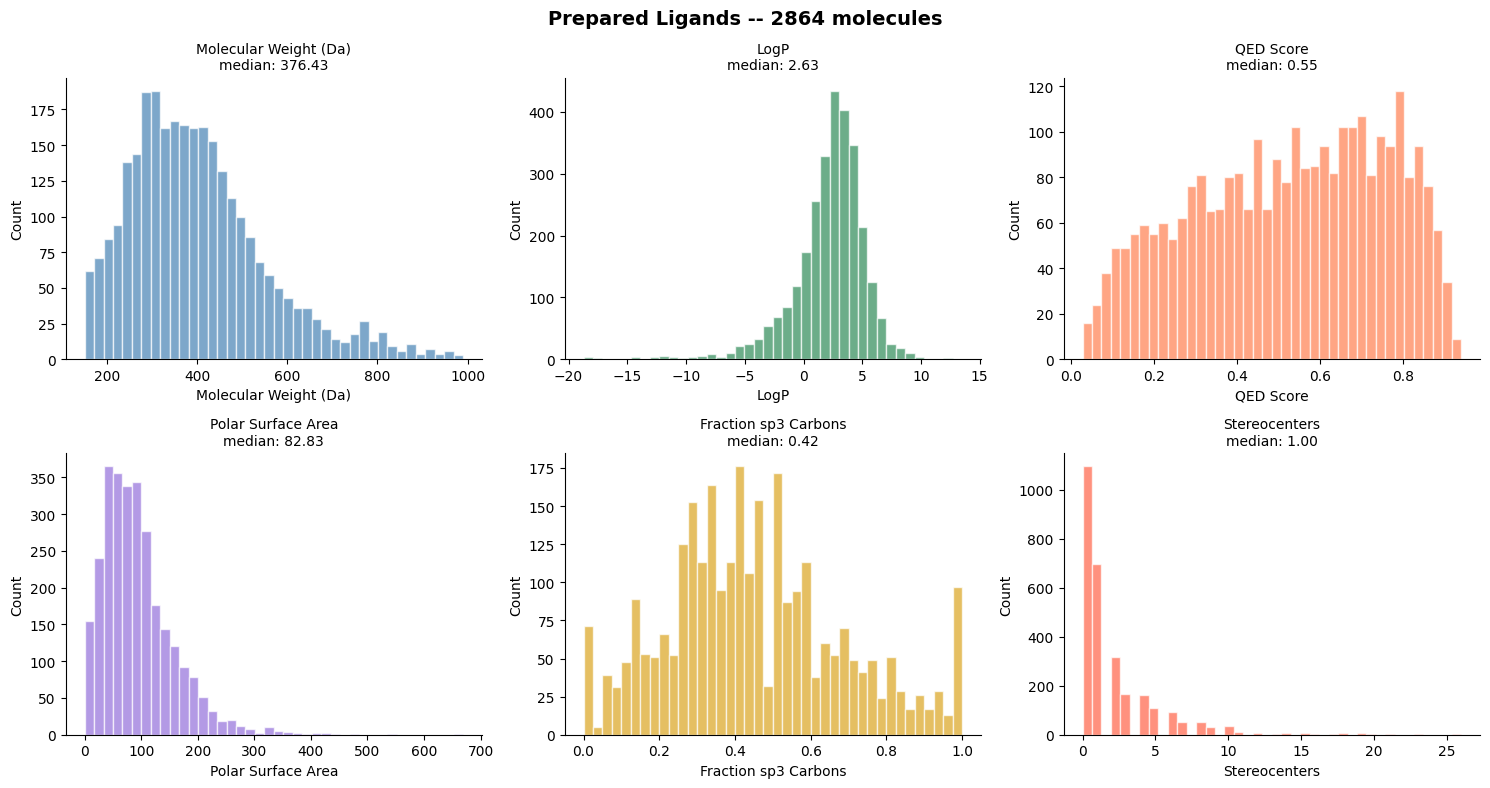

In [15]:
conn = sqlite3.connect(DB_PATH)

status_counts = pd.read_sql(
    'SELECT status, COUNT(*) as count FROM molecules GROUP BY status', conn
)
df_success = pd.read_sql(
    'SELECT * FROM molecules WHERE status = "success"', conn
)
df_failed = pd.read_sql(
    'SELECT chembl_id, name, status, failure_reason FROM molecules WHERE status NOT IN ("success", "pending")', conn
)
known_hits = pd.read_sql(
    'SELECT chembl_id, name FROM molecules WHERE status = "success" AND known_antifungal = 1', conn
)
conn.close()

print('=' * 60)
print('PIPELINE SUMMARY')
print('=' * 60)
print(status_counts.to_string(index=False))

if len(df_success) > 0:
    print(f'\nSuccessful molecules: {len(df_success)}')
    print(f'  Lipinski compliant: {df_success["lipinski_pass"].sum()}')
    print(f'  Veber compliant: {df_success["veber_pass"].sum()}')
    print(f'  Brenk clean: {df_success["brenk_pass"].sum()}')
    print(f'  Median QED: {df_success["qed_score"].median():.3f}')
    print(f'  Median MW: {df_success["molecular_weight"].median():.1f} Da')

if len(known_hits) > 0:
    print(f'\nKnown antifungals in library (pipeline validation):')
    for _, row in known_hits.iterrows():
        print(f'  {row["chembl_id"]}: {row["name"]}')

if len(df_failed) > 0:
    print(f'\nFailed molecules: {len(df_failed)}')
    print(df_failed['failure_reason'].value_counts().to_string())

# Plot
if len(df_success) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'Prepared Ligands -- {len(df_success)} molecules', fontsize=14, fontweight='bold')
    plot_configs = [
        ('molecular_weight', 'Molecular Weight (Da)', 'steelblue'),
        ('alogp', 'LogP', 'seagreen'),
        ('qed_score', 'QED Score', 'coral'),
        ('psa', 'Polar Surface Area', 'mediumpurple'),
        ('fsp3', 'Fraction sp3 Carbons', 'goldenrod'),
        ('num_stereocenters', 'Stereocenters', 'tomato')
    ]
    for ax, (col, label, color) in zip(axes.flat, plot_configs):
        data = df_success[col].dropna()
        ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
        ax.set_xlabel(label, fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.set_title(f'{label}\nmedian: {data.median():.2f}', fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig_path = Path(output_dir_widget.value).parent / 'ligand_preparation_statistics.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'\nFigure saved: {fig_path}')
    plt.show()

### Cell 10 -- Example database queries

In [ ]:
conn = sqlite3.connect(DB_PATH)

print('Top 10 molecules by QED score:')
display(pd.read_sql('''
    SELECT chembl_id, name, molecular_weight, alogp, qed_score
    FROM molecules WHERE status = 'success'
    ORDER BY qed_score DESC LIMIT 10
''', conn))

print('\nMolecules that failed 3D generation (candidates for OpenBabel retry):')
df_retry = pd.read_sql(
    'SELECT chembl_id, name, failure_reason FROM molecules WHERE status = "failed_3d" LIMIT 10',
    conn
)
if len(df_retry) > 0:
    display(df_retry)
else:
    print('None -- all molecules processed successfully.')

print('\nKnown antifungals present (pipeline validation):')
df_af = pd.read_sql(
    'SELECT chembl_id, name, status, molecular_weight FROM molecules WHERE known_antifungal = 1',
    conn
)
if len(df_af) > 0:
    display(df_af)
else:
    print('None found.')

conn.close()

### Cell 11 -- Export failed molecules for OpenBabel retry

In [ ]:
conn = sqlite3.connect(DB_PATH)
df_failed_3d = pd.read_sql(
    'SELECT chembl_id, name, smiles FROM molecules WHERE status = "failed_3d"',
    conn
)
conn.close()

if len(df_failed_3d) == 0:
    print('No failed_3d molecules. Nothing to export.')
else:
    retry_path = Path(output_dir_widget.value).parent / 'retry_obabel.smi'
    with open(retry_path, 'w') as f:
        for _, row in df_failed_3d.iterrows():
            name = str(row['name']).replace(' ', '_')
            f.write(f"{row['smiles']} {row['chembl_id']}_{name}\n")
    print(f'Exported {len(df_failed_3d)} molecules for OpenBabel retry.')
    print(f'File: {retry_path}')
    print(f'\nTo retry with OpenBabel run:')
    print(f'obabel {retry_path} -O retry_output.sdf --gen3d')

---
## What comes next

The ligand library is prepared. Every molecule has a PDBQT file and a full database record.

**Notebook 03** downloads the CYP51 crystal structures from the Protein Data Bank, prepares the receptor files, defines the binding site grid box, and runs AutoDock Vina.

**GitHub:** https://github.com/sardism/BasementDrugDiscovery

**Note:** All results are computational predictions requiring experimental validation.